## setup

In [2]:
import pandas as pd 
import textdescriptives as td
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

# !python -m spacy download en_core_web_md
# nlp = spacy.load('en_core_web_md')  

In [ ]:
# df_inter = pd.read_csv(r'/work/PENPAL/PENPAL_analysis/data/TEXT/interim/interaction_level_stories_filtered.csv')
df_full = pd.read_csv('/work/PENPAL/PENPAL_analysis/data/TEXT/interim/stories_full_text_filtered.csv')

In [7]:
df_full

,conversation_id,full_user,full_ai,language,client_id,workshop_id,timestamp,full_story
0,conv_006cb479-ccd3-40d1-83fb-4b614573f636,This is the story of\n\nThere once was a young...,"with her best friend, leaving her feeling shat...",NaN,NaN,NaN,2025-11-13 12:34:34.539000+00:00,This is the story of\n\nThere once was a young...
1,conv_06d092f9-8297-41db-8af0-820f4e274fc2,This is the story of. Something in the shadows...,"a small, seaside town, hidden away from the re...",NaN,NaN,NaN,2025-10-21 11:36:14.377000+00:00,"This is the story of. a small, seaside town, h..."
2,conv_07ec1a21-00a8-494b-9747-ef2f719abd5a,This is the story of. She looked at the dark s...,a lighthouse keeper who forgot how to sleep.\n...,NaN,NaN,NaN,2025-11-11 16:09:45.732000+00:00,This is the story of. a lighthouse keeper who ...
3,conv_09d881cc-f751-4c13-99b4-1c61d241aed5,"This is the story of\n\nthe wizard Lizard, who...","One day, while wandering through the Enchanted...",NaN,NaN,NaN,2025-10-16 13:24:27.685000+00:00,"This is the story of\n\nthe wizard Lizard, who..."
4,conv_0b515949-4de8-486e-be19-8654481a44cc,This is the story of.,a young girl named Sophia who lived in a small...,NaN,NaN,NaN,2025-11-06 13:13:43.031000+00:00,This is the story of. a young girl named Sophi...
...,...,...,...,...,...,...,...,...
58,conv_e335739c-0072-4945-8fe4-457a04c0997b,"This is the story of\n\nOnce upon a time, ther...","to the diamond mine, their joyful voices echoi...",NaN,NaN,NaN,2025-11-11 17:17:20.655000+00:00,"This is the story of\n\nOnce upon a time, ther..."
59,conv_e4cddf1d-da8c-42d7-8e64-21bbe9af1362,Child. The child was a small child. And was ve...,Let's simplify and dive into the story:\n\nThi...,NaN,NaN,NaN,2025-10-22 16:30:06.546000+00:00,Child. The child was a small child. And was ve...
60,conv_f1cbc05f-72fe-49cb-b0fd-3c97f02e3c09,This is the story of. Twice at one's reflectio...,"...a young woman named Emma, who lived in a sm...",NaN,NaN,NaN,2025-10-15 12:59:40.218000+00:00,This is the story of. ...a young woman named E...
61,conv_faa5b6a6-2a73-4e17-874a-303a86b78e65,"This is the story of\n\nA tuna, named Big Tuna...","Big Tuna, or Jim as his mother called him, was...",NaN,NaN,NaN,2025-10-10 06:55:23.828000+00:00,"This is the story of\n\nA tuna, named Big Tuna..."


## compute surface metrics

In [9]:
td.get_valid_metrics()

{'all',
 'coherence',
 'dependency_distance',
 'descriptive_stats',
 'information_theory',
 'pos_proportions',
 'quality',
 'readability'}

In [20]:
def get_descriptive_metrics_dual_long(
        df: pd.DataFrame,
        user_col: str = "full_user",
        ai_col: str = "full_ai",
        spacy_mdl: str = "en_core_web_md",
        batch_size: int = 10,
        n_process: int = 5):

    import spacy
    import textdescriptives as td
    import pandas as pd

    print(f"[INFO:] Loading spaCy model '{spacy_mdl}'...")
    nlp = spacy.load(spacy_mdl)
    nlp.add_pipe("textdescriptives/all")

    # ----- USER -----
    print(f"[INFO:] Extracting USER metrics...")
    docs_user = nlp.pipe(df[user_col], batch_size=batch_size, n_process=n_process)
    user_metrics = td.extract_df(docs_user, include_text=True)
    user_metrics.index = df.index
    user_metrics["type"] = "user"
    if "conversation_id" in df.columns:
        user_metrics["conversation_id"] = df["conversation_id"]

    # ----- AI -----
    print(f"[INFO:] Extracting AI metrics...")
    docs_ai = nlp.pipe(df[ai_col], batch_size=batch_size, n_process=n_process)
    ai_metrics = td.extract_df(docs_ai, include_text=True)
    ai_metrics.index = df.index
    ai_metrics["type"] = "ai"
    if "conversation_id" in df.columns:
        ai_metrics["conversation_id"] = df["conversation_id"]

    # ----- STACK LONG -----
    print("[INFO:] Combining metrics (long format)...")
    metrics_long = pd.concat([user_metrics, ai_metrics], axis=0)

    return metrics_long


In [21]:
df_metrics_long = get_descriptive_metrics_dual_long(
    df=df_full,
    user_col="full_user",
    ai_col="full_ai"
)

[INFO:] Loading spaCy model 'en_core_web_md'...
[INFO:] Extracting USER metrics...
[INFO:] Extracting AI metrics...
[INFO:] Combining metrics (long format)...


In [5]:
df_metrics_long = pd.read_parquet('/work/PENPAL/PENPAL_analysis/data/TEXT/processed/surface_metrics.parquet')

/work/PENPAL/venv/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/work/PENPAL/venv/lib/python3.12/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/work/PENPAL/venv/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/work/PENPAL/venv/lib/python3.12/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and wi

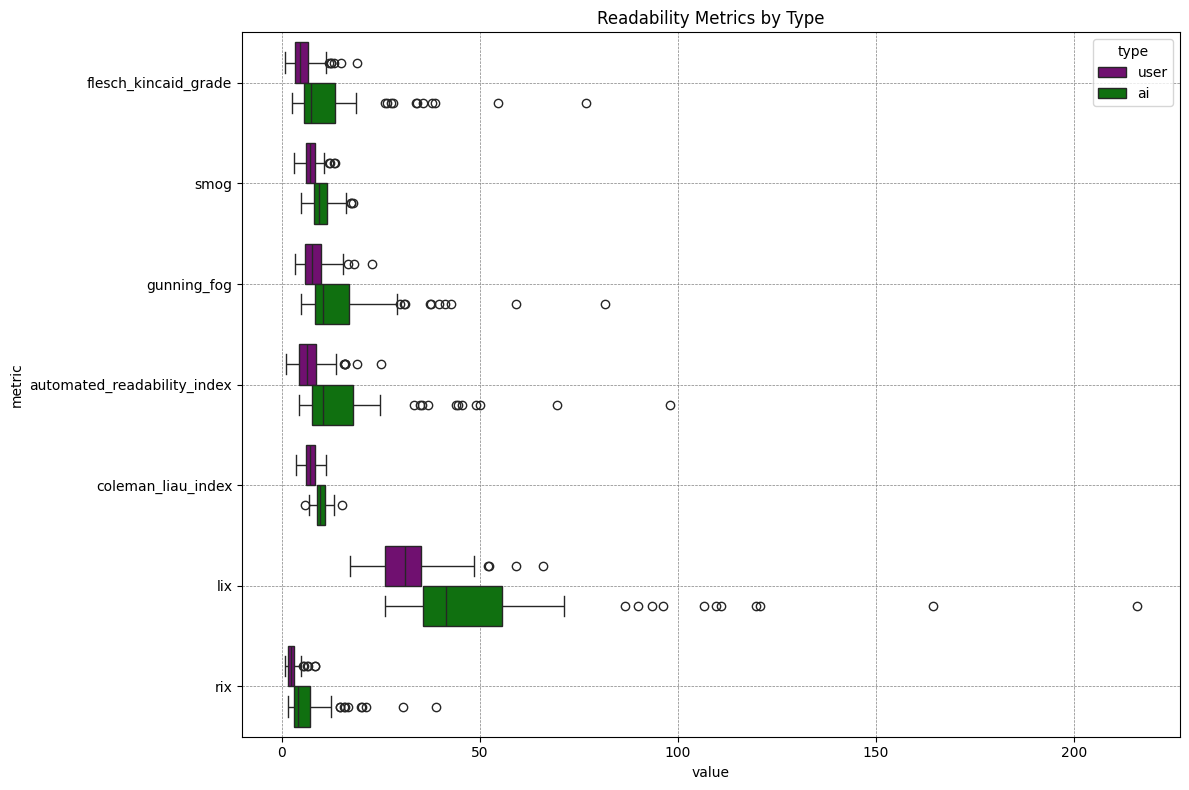

In [6]:
readability = ['flesch_kincaid_grade', 'smog',
       'gunning_fog', 'automated_readability_index', 'coleman_liau_index',
       'lix', 'rix']

df_long = df_metrics_long.melt(id_vars='type', value_vars=readability, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # readability metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)
plt.title('Readability Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()


/work/PENPAL/venv/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/work/PENPAL/venv/lib/python3.12/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/work/PENPAL/venv/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/work/PENPAL/venv/lib/python3.12/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and wi

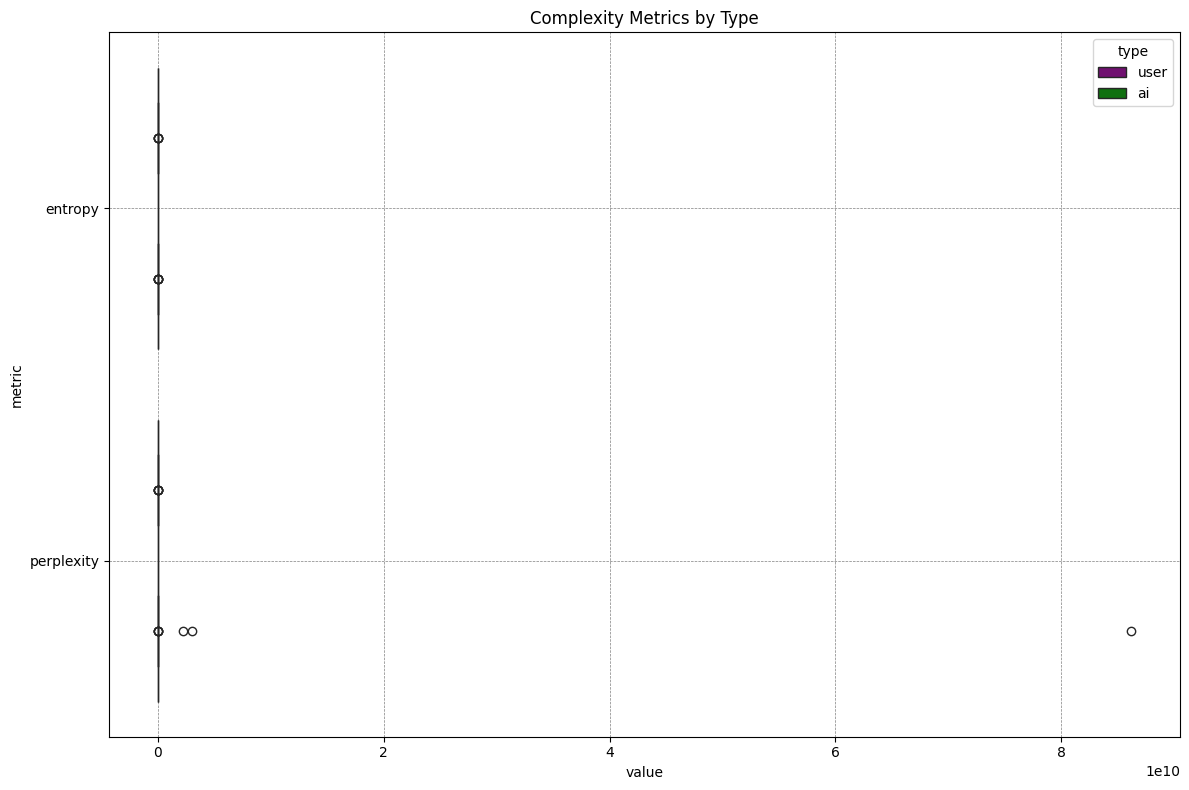

In [7]:
complexity = ['entropy', 'perplexity']
df_long = df_metrics_long.melt(id_vars='type', value_vars=complexity, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)


plt.title('Complexity Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()


/work/PENPAL/venv/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/work/PENPAL/venv/lib/python3.12/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/work/PENPAL/venv/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/work/PENPAL/venv/lib/python3.12/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and wi

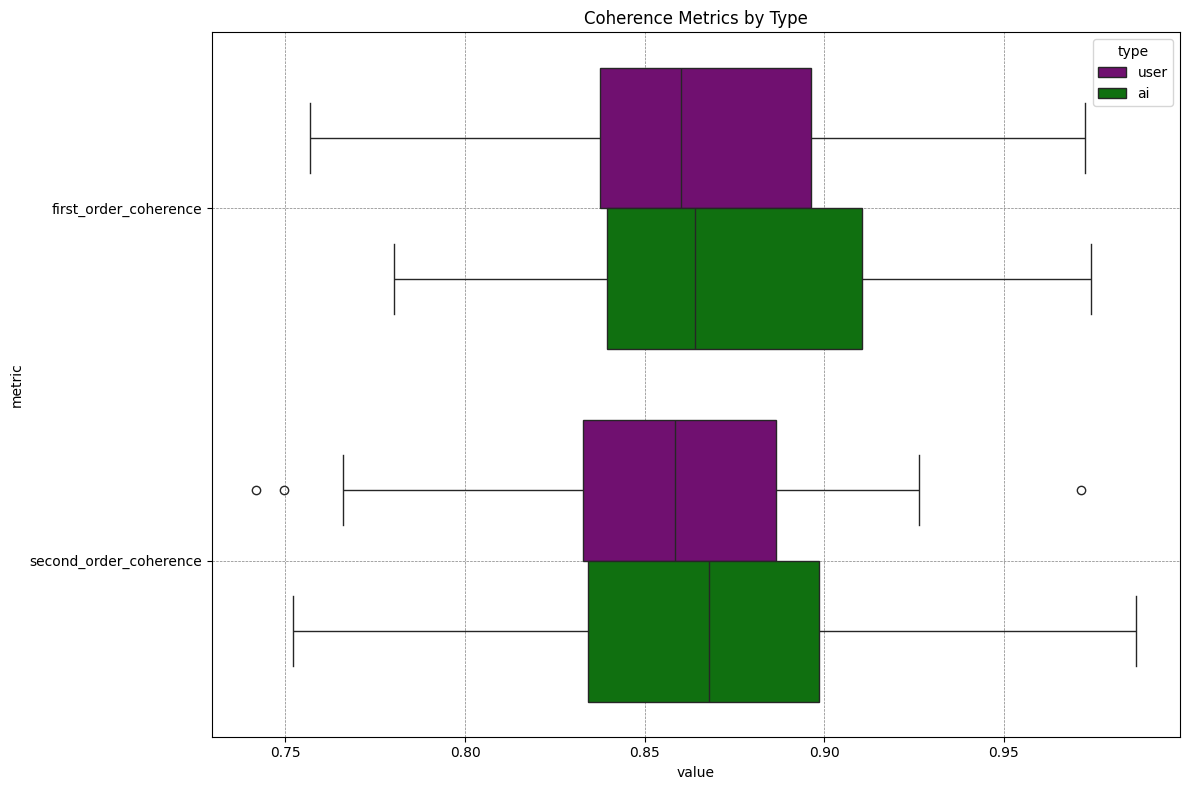

In [8]:
coherence = ['first_order_coherence', 'second_order_coherence']
df_long = df_metrics_long.melt(id_vars='type', value_vars=coherence, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)
plt.title('Coherence Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()

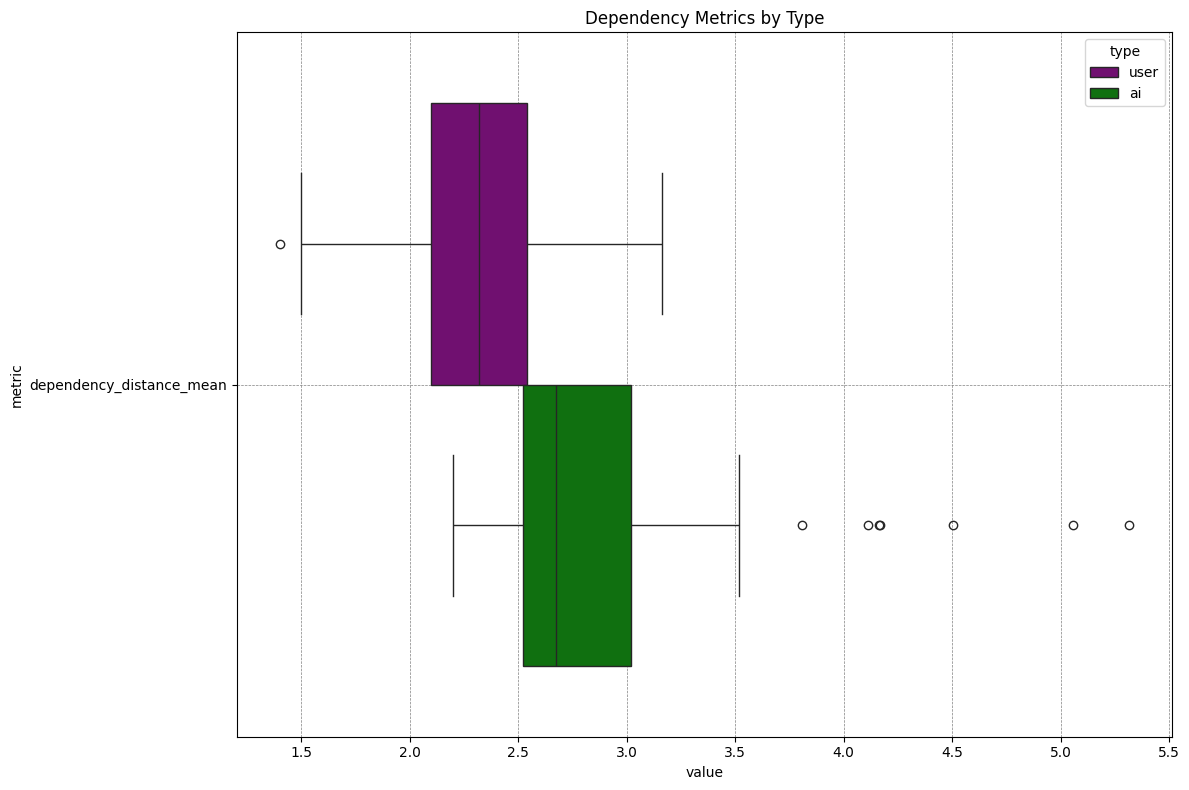

In [44]:
dependency = ['dependency_distance_mean']
df_long = df_metrics_long.melt(id_vars='type', value_vars=dependency, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)
plt.title('Dependency Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()

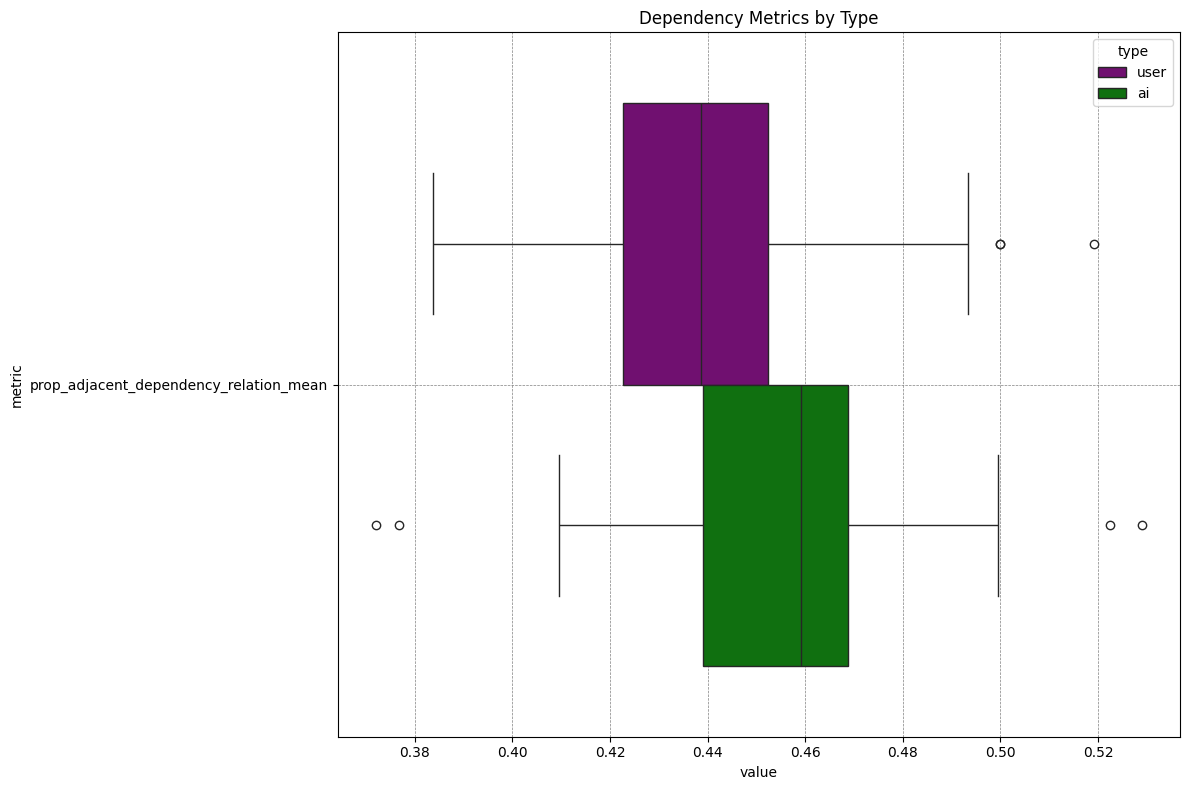

In [45]:
dependency = ['prop_adjacent_dependency_relation_mean']
df_long = df_metrics_long.melt(id_vars='type', value_vars=dependency, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)
plt.title('Dependency Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()

### Overview

In [4]:
df = pd.read_parquet('/work/PENPAL/PENPAL_analysis/data/TEXT/processed/surface_metrics.parquet')
# df = df_metrics_long.copy()

In [5]:
pos_names = {
'ADJ': 'adjective',
'ADP': 'adposition',
'ADV': 'adverb',
'AUX': 'auxiliary',
'CCONJ': 'coordinating conjunction',
'DET': 'determiner',
'INTJ': 'interjection',
'NOUN': 'noun',
'NUM': 'numeral',
'PART': 'particle',
'PRON': 'pronoun',
'PROPN': 'proper noun',
'PUNCT': 'punctuation',
'SCONJ': 'subordinating conjunction',
'SYM': 'symbol',
'VERB': 'verb',
'X': 'other',
}

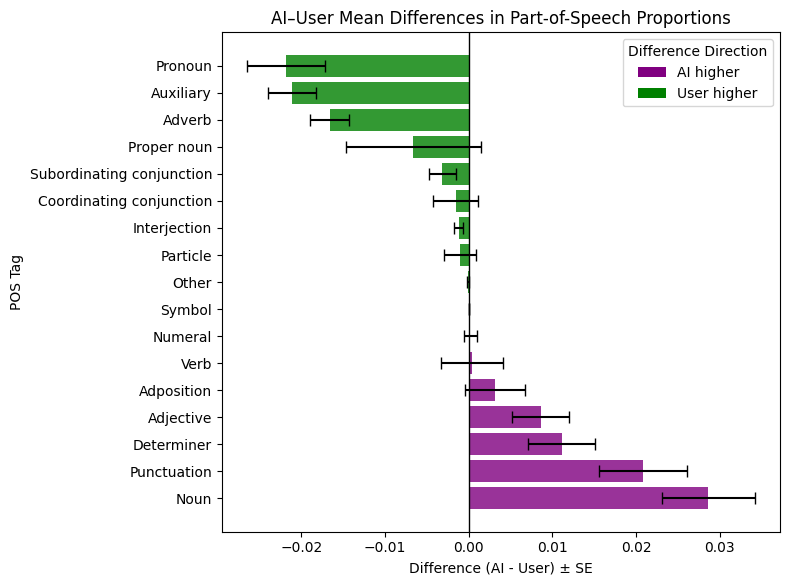

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

metrics = [col for col in df.columns if col.startswith('pos_')]

# Compute group stats
group_means = df.groupby('type')[metrics].mean().T
group_sds = df.groupby('type')[metrics].std().T
group_ns = df['type'].value_counts()

# Standard error of the difference: sqrt(s1²/n1 + s2²/n2)
se_diff = np.sqrt(
    (group_sds['ai']**2 / group_ns['ai']) +
    (group_sds['user']**2 / group_ns['user'])
)

# Difference in means
group_means['diff'] = group_means['ai'] - group_means['user']
group_means['se_diff'] = se_diff

# Sort for display
subset = group_means.sort_values('diff', ascending=False)
subset = subset.rename(index = lambda col: pos_names.get(col.split('_')[-1], col).capitalize())

# --- Plot ---
plt.figure(figsize=(8, max(4, len(subset)*0.35)))
colors = subset['diff'].apply(lambda x: 'purple' if x > 0 else 'green')


plt.barh(
    subset.index,
    subset['diff'],
    xerr=subset['se_diff'],
    color=colors,
    # ecolor=colors,          # match bar color
    capsize=4,
    alpha=0.8
)

plt.axvline(0, color='black', linewidth=1)
plt.title("AI–User Mean Differences in Part-of-Speech Proportions")
plt.xlabel("Difference (AI - User) ± SE")
plt.ylabel("POS Tag")

legend_elements = [
    Patch(facecolor='purple', label='AI higher'),
    Patch(facecolor='green', label='User higher')
]

plt.legend(handles=legend_elements, title="Difference Direction")

plt.tight_layout()
plt.show()


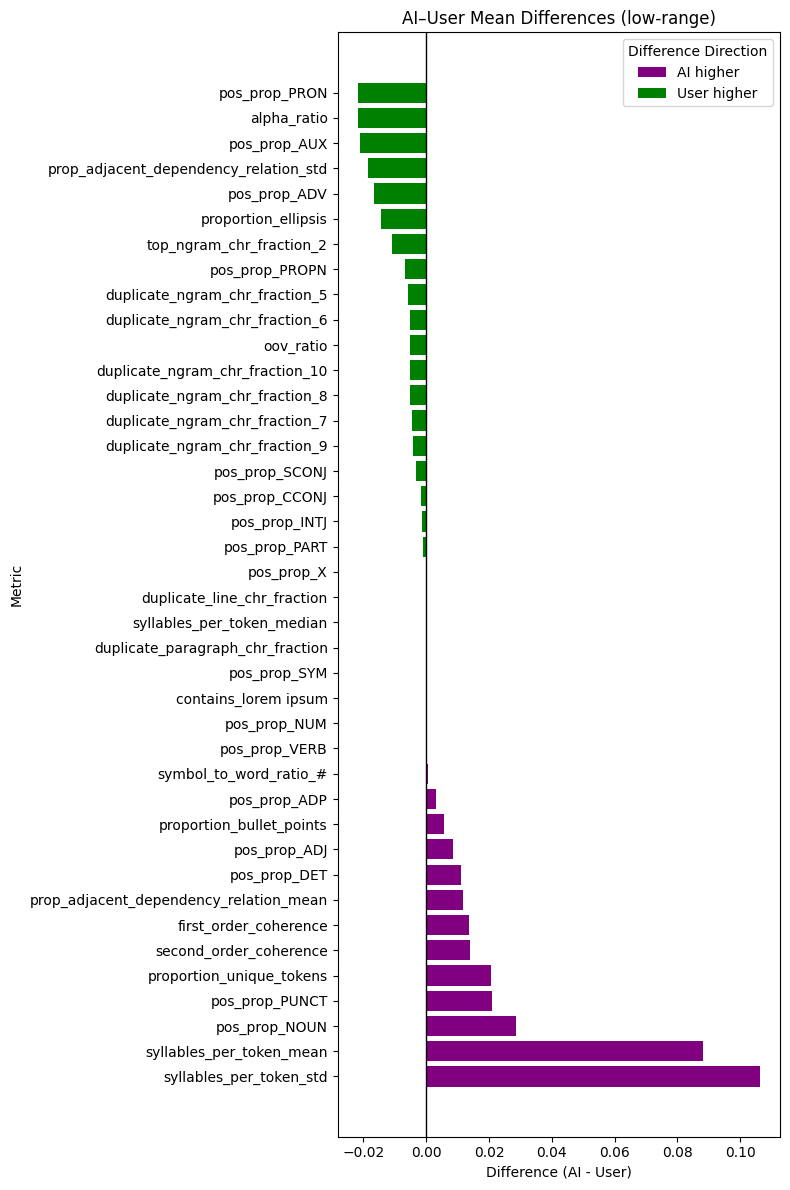

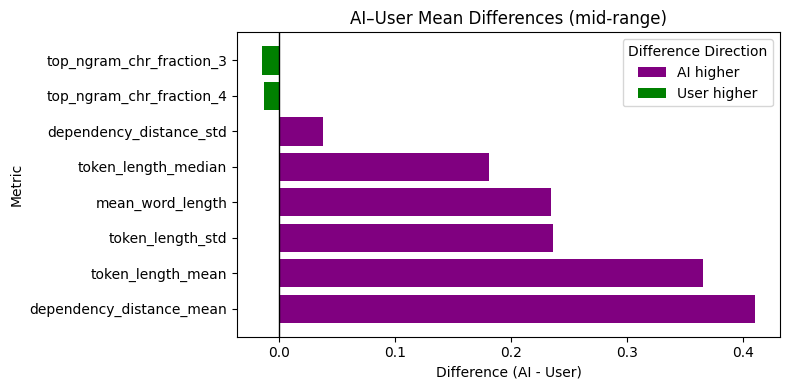

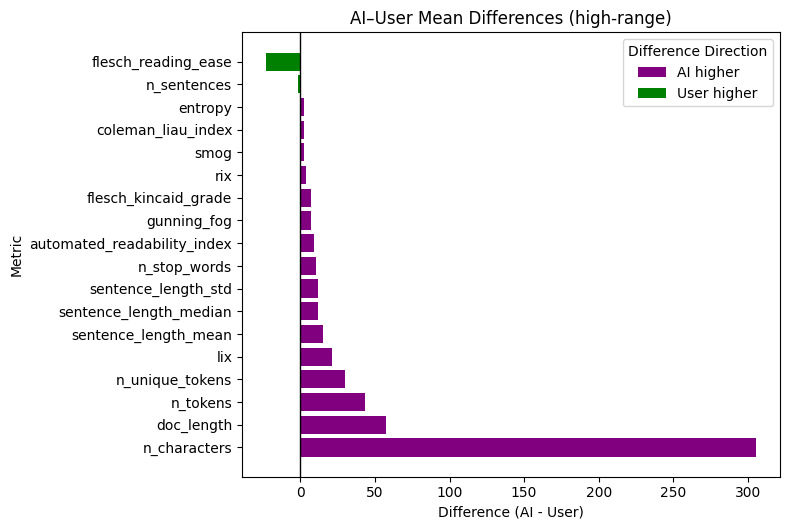

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Setup ---
df_numeric = df.select_dtypes('number')
metrics = [col for col in df_numeric.columns if col != 'per_word_perplexity' and col != 'perplexity']

# Compute mean per type
group_means = df.groupby('type')[metrics].mean().T
group_means['diff'] = group_means['ai'] - group_means['user']

# Compute ranges for grouping
min_vals = df_numeric.min()
max_vals = df_numeric.max()
ranges = max_vals - min_vals

# Define thresholds (tune if needed)
low_thr, mid_thr = 1, 10  # <1 small fractions, 1–10 mid, >10 high-range metrics

# Assign each metric to a scale group
scale_group = pd.cut(ranges, 
                     bins=[-np.inf, low_thr, mid_thr, np.inf], 
                     labels=['low-range', 'mid-range', 'high-range'])

group_means['scale_group'] = scale_group

# --- Plot each scale group separately ---
for group in ['low-range', 'mid-range', 'high-range']:
    subset = group_means[group_means['scale_group'] == group].sort_values('diff', ascending=False)
    if subset.empty:
        continue

    plt.figure(figsize=(8, max(4, len(subset)*0.3)))
    plt.barh(
        subset.index,
        subset['diff'],
        color=subset['diff'].apply(lambda x: 'purple' if x > 0 else 'green')
    )
    plt.axvline(0, color='black', linewidth=1)
    plt.title(f"AI–User Mean Differences ({group})")
    plt.xlabel("Difference (AI - User)")
    plt.ylabel("Metric")
        
    legend_elements = [
        Patch(facecolor='purple', label='AI higher'),
        Patch(facecolor='green', label='User higher')
    ]

    plt.legend(handles=legend_elements, title="Difference Direction")
    plt.tight_layout()
    plt.show()


In [ ]:
for i in range(0, 100, 5): 
    print(f"Quantile: {i/100}:", f"{round(df.loc[:, 'perplexity'].quantile(q=i/100),3):2_}")

Quantile: 0.0: 18.027
Quantile: 0.05: 675.104
Quantile: 0.1: 1_185.245
Quantile: 0.15: 1_796.645
Quantile: 0.2: 2_660.318
Quantile: 0.25: 2_936.335
Quantile: 0.3: 3_812.696
Quantile: 0.35: 5_505.502
Quantile: 0.4: 6_327.474
Quantile: 0.45: 8_209.616
Quantile: 0.5: 11_731.224
Quantile: 0.55: 16_782.067
Quantile: 0.6: 19_345.499
Quantile: 0.65: 24_045.495
Quantile: 0.7: 27_234.421
Quantile: 0.75: 36_292.49
Quantile: 0.8: 45_435.25
Quantile: 0.85: 53_843.592
Quantile: 0.9: 89_197.46
Quantile: 0.95: 434_618.457


### z-scored

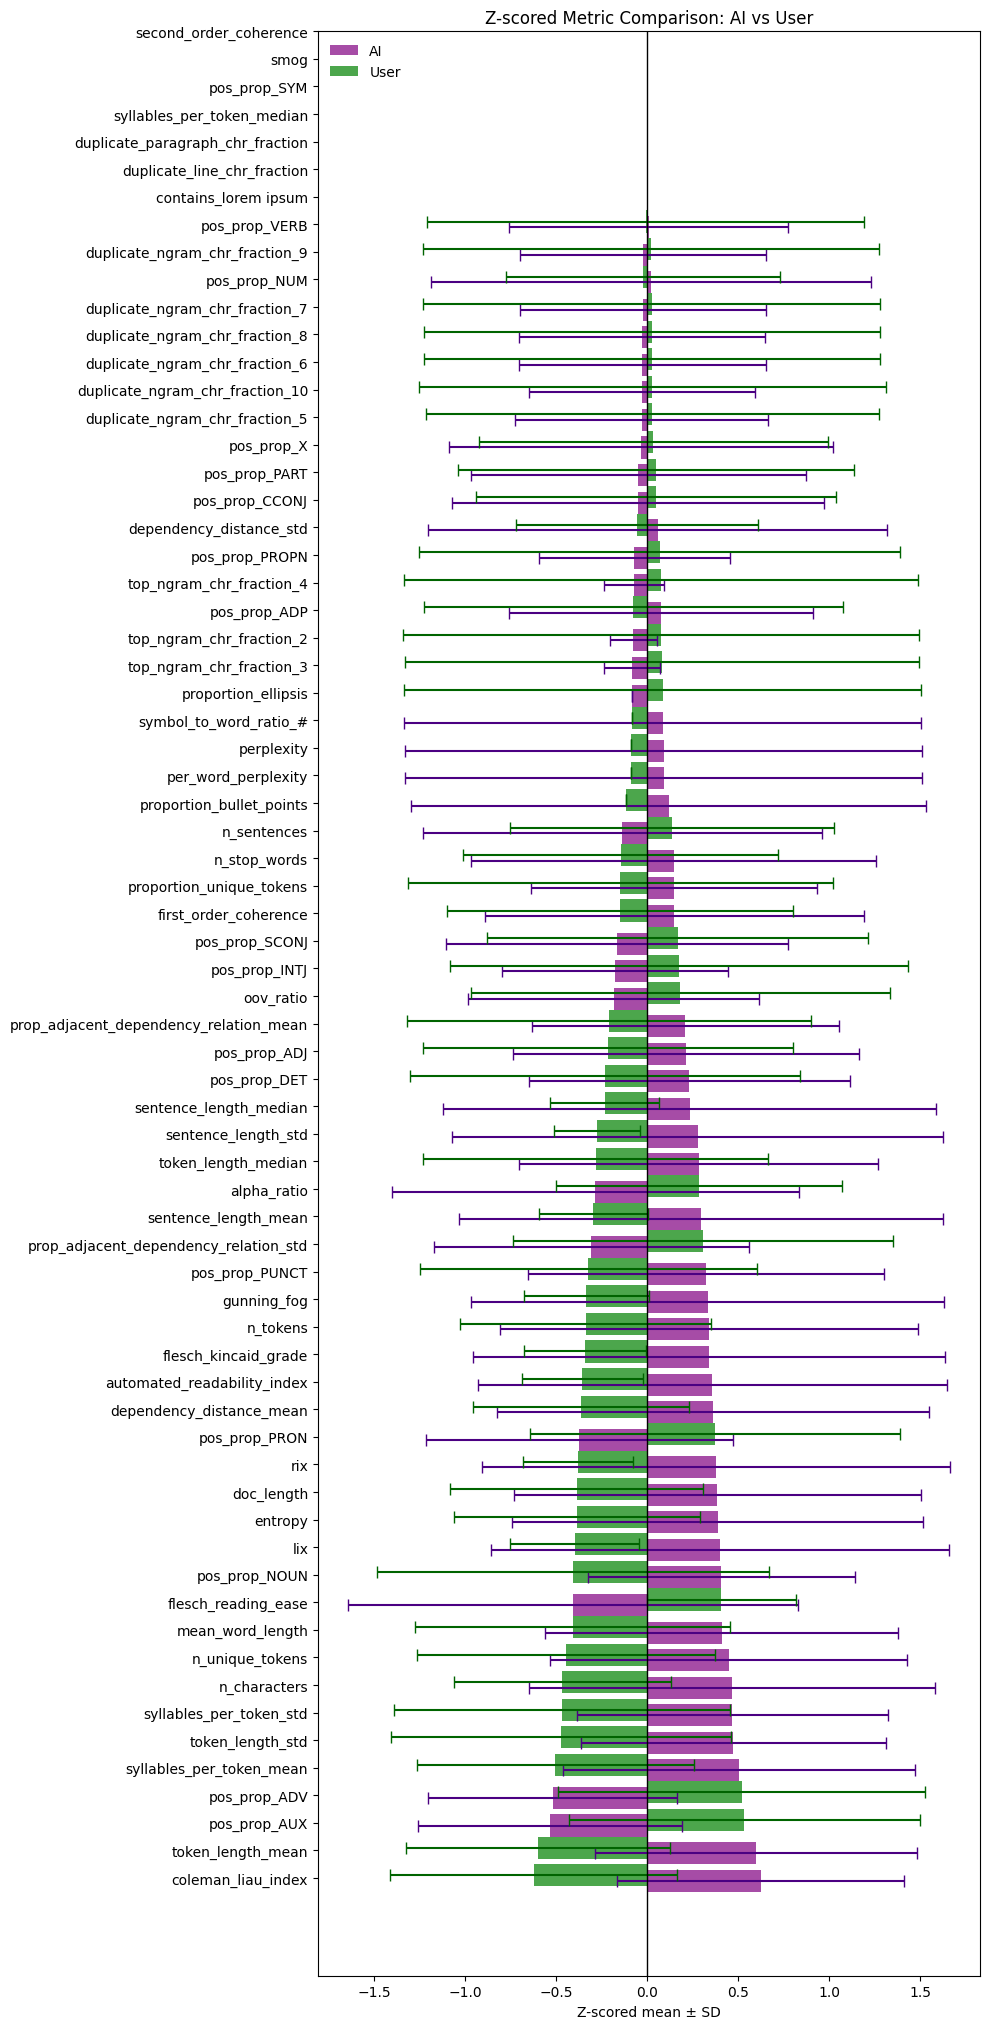

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

# --- Z-score numeric metrics ---
df_numeric = df.select_dtypes('number')
metrics = df_numeric.columns
df_z = df_numeric.apply(zscore)
df_z['type'] = df['type']

# --- Compute means & sds ---
group_means = df_z.groupby('type')[metrics].mean().T
group_sds   = df_z.groupby('type')[metrics].std().T
group_means['diff'] = group_means['ai'] - group_means['user']

# --- Sort by absolute difference ---
order = group_means['diff'].abs().sort_values(ascending=False).index
x = np.arange(len(order))
width = 0.2

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, max(5, len(metrics)*0.3)))

# AI bars with purple error bars
ax.barh(x - width/2, group_means.loc[order, 'ai'],
        xerr=group_sds.loc[order, 'ai'],
        label='AI',
        color='purple', alpha=0.7, capsize=4, ecolor='indigo')

# User bars with green error bars
ax.barh(x + width/2, group_means.loc[order, 'user'],
        xerr=group_sds.loc[order, 'user'],
        label='User',
        color='green', alpha=0.7, capsize=4, ecolor='darkgreen',)

# Cosmetic tweaks
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(x)
ax.set_yticklabels(order)
ax.set_xlabel("Z-scored mean ± SD")
ax.set_title("Z-scored Metric Comparison: AI vs User")
ax.legend(frameon=False, loc='best')
plt.tight_layout()
plt.show()


### Something else

In [16]:
df

,text,dependency_distance_mean,dependency_distance_std,prop_adjacent_dependency_relation_mean,prop_adjacent_dependency_relation_std,passed_quality_check,n_stop_words,alpha_ratio,mean_word_length,doc_length,...,coleman_liau_index,lix,rix,first_order_coherence,second_order_coherence,entropy,perplexity,per_word_perplexity,type,conversation_id
0,This is the story of\n\nThere once was a young...,2.440512,0.781017,0.432219,0.142975,True,134.0,0.929461,4.232365,241.0,...,8.256964,31.857143,2.500000,0.907221,0.904327,5.997056,402.242655,1.669057,user,conv_006cb479-ccd3-40d1-83fb-4b614573f636
1,"She looked at the dark sea, waiting for sign ...",2.194044,0.704978,0.441315,0.084791,True,160.0,0.897959,3.772109,294.0,...,5.983270,25.317300,1.600000,0.833214,0.844936,9.778132,17643.660454,60.012451,user,conv_07ec1a21-00a8-494b-9747-ef2f719abd5a
2,"This is the story of\n\nJohn Cena, the famous ...",2.548199,0.847109,0.434348,0.090397,True,134.0,0.833333,3.393333,300.0,...,5.783402,32.697473,2.363636,0.895909,0.885649,7.818038,2485.024746,8.283416,user,conv_0bb56093-3033-4615-bb70-ebfa4135589a
3,This is the story of\n\na small town girl who ...,2.882427,1.223123,0.418238,0.177995,True,125.0,0.923077,4.457875,273.0,...,11.034980,59.173669,8.285714,0.875027,0.860897,7.326635,1520.256880,5.568707,user,conv_0f18b30f-7d4b-4681-b98e-a0ff4f2b5256
4,"This is the story of\n\nA young girl, riding h...",2.382906,0.945086,0.437648,0.131247,True,148.0,0.821875,3.637500,320.0,...,6.830229,30.201687,2.263158,0.805892,0.839361,10.724151,45440.118947,142.000372,user,conv_11293fd2-d757-471f-8e2e-783542167a8e
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,depth and layers I hadn't considered before. T...,2.491785,0.537798,0.432418,0.067290,True,184.0,0.882184,4.071839,348.0,...,9.025552,37.681345,3.500000,0.897238,0.894795,11.767594,129003.378049,370.699362,ai,conv_da1c7ee9-2479-4f47-94bc-db9161a6e88c
65,"to the diamond mine, their joyful voices echoi...",3.807215,0.955895,0.467276,0.011779,True,150.0,0.883234,4.173653,334.0,...,10.908123,96.116894,16.750000,0.935105,0.934643,11.500500,98765.130325,295.703983,ai,conv_e335739c-0072-4945-8fe4-457a04c0997b
66,This is the story of a lighthouse keeper who s...,2.050071,0.710189,0.441247,0.077232,True,126.0,0.835714,4.028571,280.0,...,8.330300,29.450823,1.916667,0.780339,0.802001,8.305353,4045.468953,14.448103,ai,conv_e73d720a-ff86-4c9b-b988-d6cc879215d9
67,"This is the story of a young girl named Ava, w...",3.559084,1.265750,0.492999,0.018545,True,147.0,0.892857,3.922078,308.0,...,9.193210,106.569496,14.666667,0.941037,0.933037,10.621205,40994.969947,133.100552,ai,conv_f5028a6e-05a3-4757-84d0-491a6f400c24


In [19]:
pd.read_csv('/work/PENPAL/PENPAL_analysis/data/TEXT/interim/stories_full_text_filtered.csv')

,conversation_id,full_user,full_ai,timestamp,respondent_id,starter,llm_type,full_story
0,conv_006cb479-ccd3-40d1-83fb-4b614573f636,This is the story of\n\nThere once was a young...,"with her best friend, leaving her feeling shat...",2025-11-13 12:34:34.539000+00:00,A89X12UN9Y1T,user,3,This is the story of\n\nThere once was a young...
1,conv_07ec1a21-00a8-494b-9747-ef2f719abd5a,"She looked at the dark sea, waiting for sign ...",This is the story of a lighthouse keeper who f...,2025-11-11 16:09:45.732000+00:00,4MY88EZZ8LCW,ai,2,This is the story of a lighthouse keeper who ...
2,conv_0bb56093-3033-4615-bb70-ebfa4135589a,"This is the story of\n\nJohn Cena, the famous ...","misinterpreted as ""Let's do this,"" but only hi...",2025-11-06 12:16:16.855000+00:00,VHE1FW23AMCW,user,3,"This is the story of\n\nJohn Cena, the famous ..."
3,conv_0f18b30f-7d4b-4681-b98e-a0ff4f2b5256,This is the story of\n\na small town girl who ...,She feels trapped in the mundane routine of he...,2025-11-10 19:27:13.854000+00:00,HY53S2L3H43F,user,3,This is the story of\n\na small town girl who ...
4,conv_11293fd2-d757-471f-8e2e-783542167a8e,"This is the story of\n\nA young girl, riding h...","in the sight before her. The object, which had...",2025-11-18 08:40:17.914000+00:00,L9SW1MM65H9W,user,3,"This is the story of\n\nA young girl, riding h..."
...,...,...,...,...,...,...,...,...
64,conv_da1c7ee9-2479-4f47-94bc-db9161a6e88c,This is the story of\n\nWhat does it mean to b...,depth and layers I hadn't considered before. T...,2025-11-18 11:10:56.683000+00:00,QJWLS13T5H1W,user,4,This is the story of\n\nWhat does it mean to b...
65,conv_e335739c-0072-4945-8fe4-457a04c0997b,This is the story of\n\nOnce upon a time there...,"to the diamond mine, their joyful voices echoi...",2025-11-11 17:17:20.655000+00:00,461W5T16XQ9W,user,3,This is the story of\n\nOnce upon a time there...
66,conv_e73d720a-ff86-4c9b-b988-d6cc879215d9,all the way to the top of the light house. an...,This is the story of a lighthouse keeper who s...,2025-11-17 12:12:24.650000+00:00,9UHVH9XRLD9F,ai,2,This is the story of a lighthouse keeper who ...
67,conv_f5028a6e-05a3-4757-84d0-491a6f400c24,everybody kept to themselves and did their jo...,"This is the story of a young girl named Ava, w...",2025-11-17 11:35:33.379000+00:00,HXFHNH63LZCS,ai,3,"This is the story of a young girl named Ava, ..."


In [20]:
df = pd.read_csv('/work/PENPAL/PENPAL_analysis/data/TEXT/interim/interaction_level_stories_filtered.csv')

In [21]:
df[df['starter'] == 'ai']

,timestamp,user,ai,conversation_id,respondent_id,interaction_count,llm_type,starter
10,2025-11-11 16:09:45.732000+00:00,NaN,This is the story of a lighthouse keeper who f...,conv_07ec1a21-00a8-494b-9747-ef2f719abd5a,4MY88EZZ8LCW,1.0,2,ai
11,2025-11-11 16:12:59.933000+00:00,"She looked at the dark sea, waiting for sign o...","by the thousand glowing portholes, each one a ...",conv_07ec1a21-00a8-494b-9747-ef2f719abd5a,4MY88EZZ8LCW,2.0,2,ai
12,2025-11-11 16:15:17.707000+00:00,impossible to miss. Usually the water was calm...,strangely—pulsing in rhythms that didn't match...,conv_07ec1a21-00a8-494b-9747-ef2f719abd5a,4MY88EZZ8LCW,3.0,2,ai
13,2025-11-11 16:18:12.806000+00:00,foggy in the chill night air. Without knowing ...,"of the upper decks, an answering flash—red, th...",conv_07ec1a21-00a8-494b-9747-ef2f719abd5a,4MY88EZZ8LCW,4.0,2,ai
14,2025-11-11 16:20:10.304000+00:00,"her, when she flashed the red lights. Lighthou...","a sealed letter marked ""Open only when the red...",conv_07ec1a21-00a8-494b-9747-ef2f719abd5a,4MY88EZZ8LCW,5.0,2,ai
...,...,...,...,...,...,...,...,...
685,2025-11-06 12:28:08.840000+00:00,A house. It sits above the washbasin and is gr...,"more defined, but the scene in the clearing st...",conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,6.0,4,ai
686,2025-11-06 12:28:26.672000+00:00,The neighbors all say that the dust will pass....,"own. But as Ezra and I stood there, the dust s...",conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,7.0,4,ai
687,2025-11-06 12:28:45.498000+00:00,Little Bessie and I go into town the next day ...,"cow, and she’s been a faithful companion throu...",conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,8.0,4,ai
688,2025-11-06 12:29:06.828000+00:00,"As we ride in, we see the new pop-up shop sell...","asks. But today, there's a different kind of e...",conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,9.0,4,ai


In [27]:
metrics_inter = pd.read_parquet('/work/PENPAL/PENPAL_analysis/data/TEXT/processed/interaction_level_surface_metrics.parquet')

In [23]:
metrics_inter

,text,pos_prop_ADJ,pos_prop_ADP,pos_prop_ADV,pos_prop_AUX,pos_prop_CCONJ,pos_prop_DET,pos_prop_INTJ,pos_prop_NOUN,pos_prop_NUM,...,smog,gunning_fog,automated_readability_index,coleman_liau_index,lix,rix,type,interaction_count,starter,conversation_id
0,This is the story of\n\nThere once was a young...,0.033333,0.100000,0.066667,0.133333,0.000000,0.066667,0.0,0.233333,0.0,...,NaN,5.600000,3.568929,4.555714,24.714286,1.500000,user,1.0,user,conv_006cb479-ccd3-40d1-83fb-4b614573f636
1,who claimed they loved her. This made her hard...,0.137931,0.068966,0.103448,0.034483,0.068966,0.000000,0.0,0.034483,0.0,...,3.129100,3.600000,2.782222,5.520000,20.111111,1.000000,user,2.0,user,conv_006cb479-ccd3-40d1-83fb-4b614573f636
2,that she meet another young woman just like he...,0.107143,0.071429,0.142857,0.000000,0.035714,0.035714,0.0,0.178571,0.0,...,NaN,8.276923,6.446154,8.609231,28.384615,2.000000,user,3.0,user,conv_006cb479-ccd3-40d1-83fb-4b614573f636
3,as if they where destined to meet. They starte...,0.066667,0.100000,0.033333,0.000000,0.066667,0.033333,0.0,0.066667,0.0,...,3.129100,3.733333,2.749524,5.388571,27.190476,1.666667,user,4.0,user,conv_006cb479-ccd3-40d1-83fb-4b614573f636
4,time whent on their connection became more tha...,0.105263,0.157895,0.052632,0.000000,0.000000,0.052632,0.0,0.263158,0.0,...,6.427356,4.622222,3.026667,6.053333,17.111111,0.666667,user,5.0,user,conv_006cb479-ccd3-40d1-83fb-4b614573f636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,"more defined, but the scene in the clearing st...",0.093750,0.093750,0.093750,0.000000,0.062500,0.156250,0.0,0.218750,0.0,...,NaN,8.362963,8.521111,10.971852,39.425926,3.500000,ai,6.0,ai,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec
686,"own. But as Ezra and I stood there, the dust s...",0.088235,0.029412,0.058824,0.029412,0.058824,0.088235,0.0,0.117647,0.0,...,6.427356,5.245977,3.055402,5.671724,20.011494,1.000000,ai,7.0,ai,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec
687,"cow, and she’s been a faithful companion throu...",0.117647,0.088235,0.029412,0.058824,0.058824,0.117647,0.0,0.205882,0.0,...,NaN,8.666667,5.852000,6.922667,35.000000,3.000000,ai,8.0,ai,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec
688,"asks. But today, there's a different kind of e...",0.088235,0.147059,0.000000,0.029412,0.029412,0.176471,0.0,0.264706,0.0,...,8.841846,8.019048,5.440952,8.748571,41.476190,3.000000,ai,9.0,ai,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec


/work/PENPAL/venv/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/work/PENPAL/venv/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


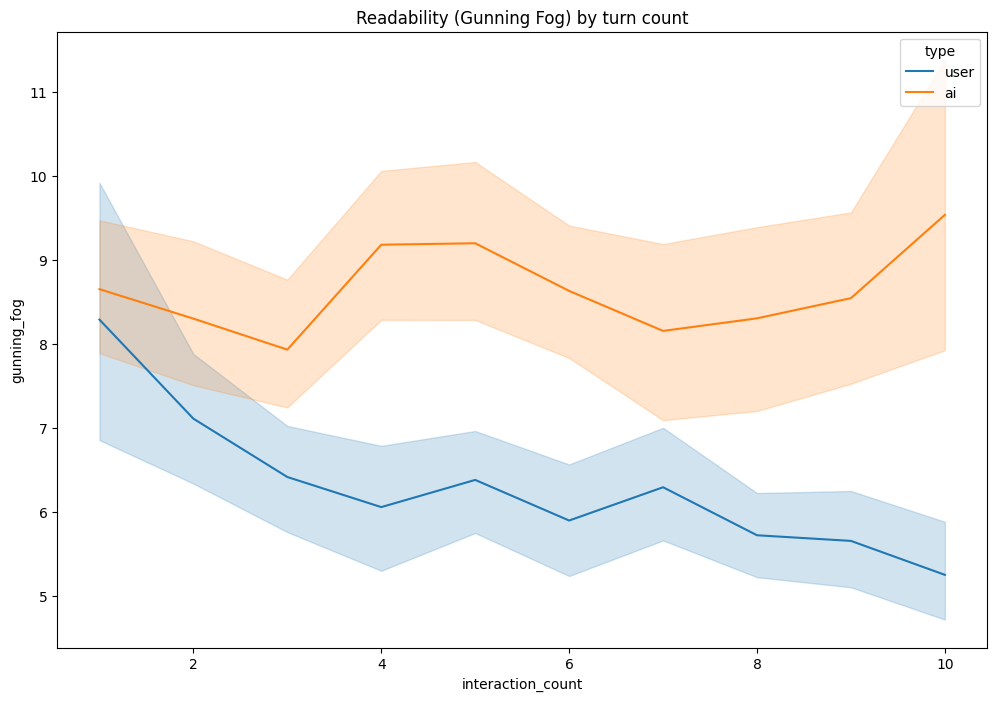

In [30]:
plt.figure(figsize=(12,8))
sns.lineplot(data=metrics_inter, x='interaction_count', y='gunning_fog', hue='type')
plt.title('Readability (Gunning Fog) by turn count')
plt.show()

In [ ]:
pos_names = {
'ADJ': 'adjective',
'ADP': 'adposition',
'ADV': 'adverb',
'AUX': 'auxiliary',
'CCONJ': 'coordinating conjunction',
'DET': 'determiner',
'INTJ': 'interjection',
'NOUN': 'noun',
'NUM': 'numeral',
'PART': 'particle',
'PRON': 'pronoun',
'PROPN': 'proper noun',
'PUNCT': 'punctuation',
'SCONJ': 'subordinating conjunction',
'SYM': 'symbol',
'VERB': 'verb',
'X': 'other',
}

In [ ]:
df = metrics_inter.copy()
metrics = [col for col in df.columns if col.startswith('pos_')]

plt.figure(figsize=(12,8))
sns.lineplot(data=df, x='interaction_count', y='gunning_fog', hue='type')
plt.title('Readability (Gunning Fog) by turn count')
plt.show()